# Yash Bhardwaj
## Practical-2
### Multiple Linear Regression / Regression Models

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

In [84]:
df=pd.read_csv('USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81,USS Barnett\nFPO AP 44820
4,59982.20,5.04,7.84,4.23,26354.11,630943.49,USNS Raymond\nFPO AE 09386


In [85]:
df.tail()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
4995,60567.94,7.83,6.14,3.46,22837.36,1060193.79,USNS Williams\nFPO AP 30153-7653
4996,78491.28,7.00,6.58,4.02,25616.12,1482617.73,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.69,7.25,4.81,2.13,33266.15,1030729.58,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.33,5.53,7.13,5.44,42625.62,1198656.87,USS Wallace\nFPO AE 73316
4999,65510.58,5.99,6.79,4.07,46501.28,1298950.48,"37778 George Ridges Apt. 509\nEast Holly, NV 2..."


In [86]:
print(df.shape)

(5000, 7)


In [87]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,68583.11,5.98,6.99,3.98,36163.52,1232072.65
std,10657.99,0.99,1.01,1.23,9925.65,353117.63
min,17796.63,2.64,3.24,2.00,172.61,15938.66
25%,61480.56,5.32,6.30,3.14,29403.93,997577.14
50%,68804.29,5.97,7.00,4.05,36199.41,1232669.38
75%,75783.34,6.65,7.67,4.49,42861.29,1471210.20
max,107701.75,9.52,10.76,6.50,69621.71,2469065.59


In [88]:
pd.set_option('display.float_format','{:.2f}'.format)

In [89]:
df.drop("Address",axis=1,inplace=True)

In [90]:
print(df.shape)

(5000, 6)


In [91]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
dtype: int64

In [92]:
df.duplicated().sum()

np.int64(0)

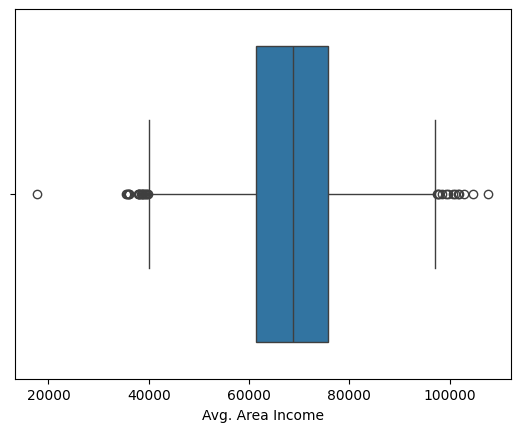

In [93]:
sns.boxplot(x=df["Avg. Area Income"])
plt.show()

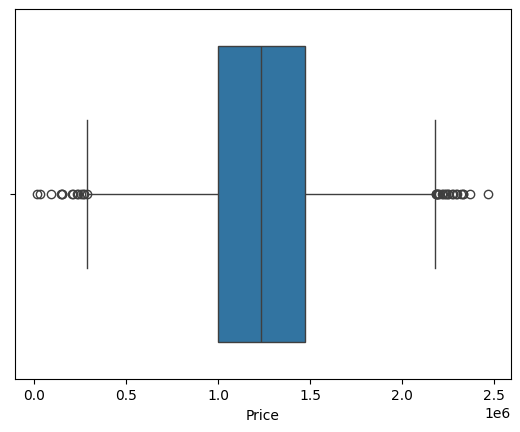

In [94]:
sns.boxplot(x=df["Price"])
plt.show()

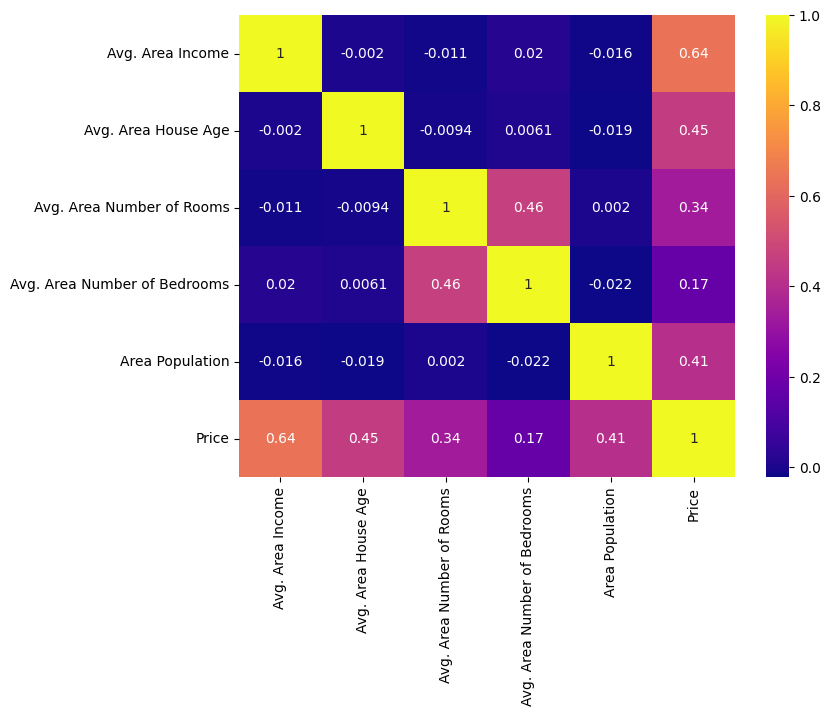

In [95]:
plt.figure(figsize=(8,6))
numeric_df=df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),
annot=True,
cmap='plasma')
plt.show()

In [96]:
Q1=df["Avg. Area Income"].quantile(0.25)
Q3=df["Avg. Area Income"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df=df[(df["Avg. Area Income"]>=lower)&(df["Avg. Area Income"] <=upper)]

In [97]:
Q1=df["Price"].quantile(0.25)
Q3=df["Price"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df=df[(df["Price"]>=lower)&(df["Price"] <=upper)]

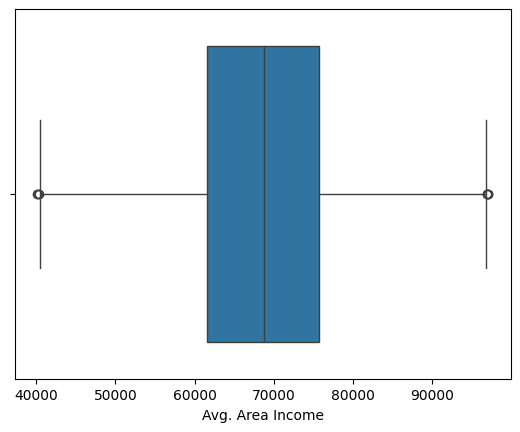

In [98]:
sns.boxplot(x=df["Avg. Area Income"])
plt.show()

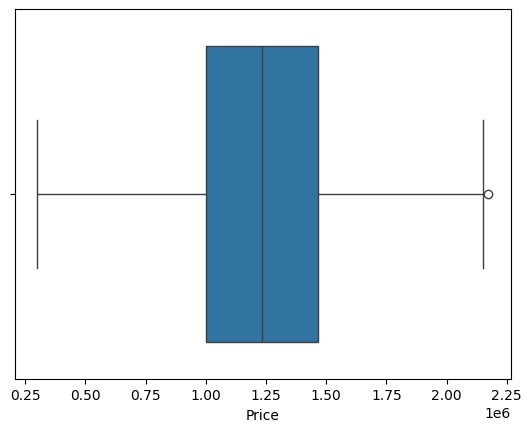

In [99]:
sns.boxplot(x=df["Price"])
plt.show()

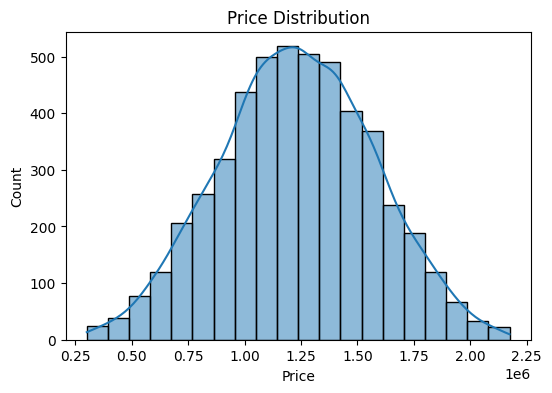

In [100]:
plt.figure(figsize=(6,4))
sns.histplot(df["Price"],bins=20,kde=True)

plt.title("Price Distribution")
plt.show()

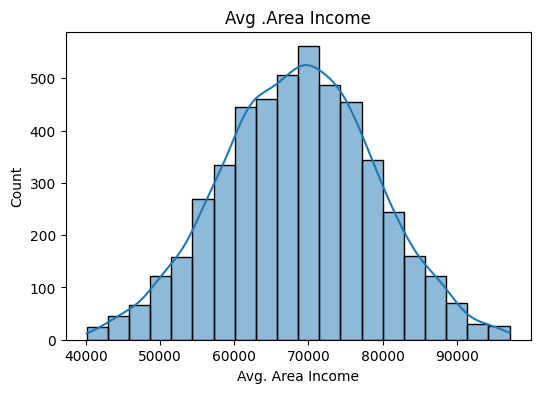

In [101]:
plt.figure(figsize=(6,4))
sns.histplot(df["Avg. Area Income"],bins=20,kde=True)

plt.title("Avg .Area Income")
plt.show()

In [102]:
X=df[['Avg. Area Income']]
y=df[['Price']]

In [103]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [104]:
from sklearn.linear_model import LinearRegression

slr_model=LinearRegression()
slr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[20.48]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Avg. Area Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-174255.61]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [105]:
y_pred=slr_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [107]:
print("Simple Linear Regression Results")
print("--------------------------------")

print("MAE:",mean_absolute_error(y_test,y_pred))

Simple Linear Regression Results
--------------------------------
MAE: 216087.7143550425


In [108]:
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_absolute_error(y_test,y_pred)))
print("R^2 Score:",r2_score(y_test,y_pred))

MSE: 70880962067.4512
RMSE: 464.8523575879147
R^2 Score: 0.3983053580403858


In [109]:
print("Intercept:",slr_model.intercept_)
print("Slope:",slr_model.coef_[0])

Intercept: [-174255.61105124]
Slope: [20.47908507]


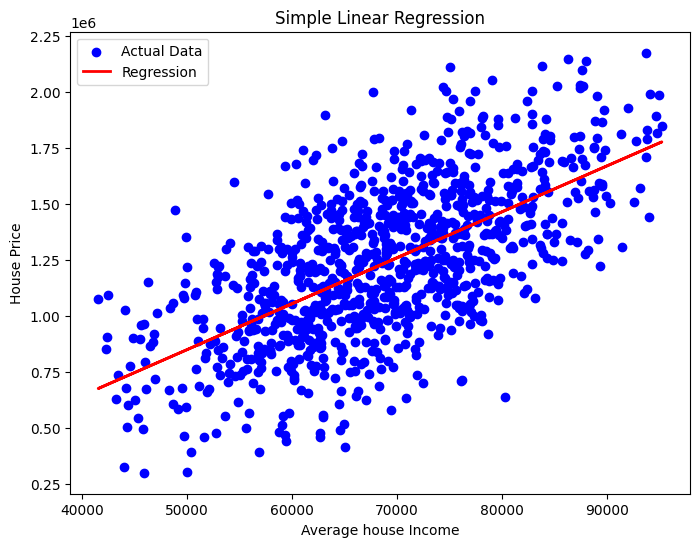

In [110]:
plt.figure(figsize=(8,6))
plt.scatter(X_test,y_test,color='blue',label='Actual Data')
plt.plot(X_test,y_pred,color='red',linewidth=2,label='Regression')
plt.xlabel("Average house Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [111]:
income = float(input("Enter Average Area Income:"))
new_data = np.array([[income]])

In [112]:
prediction = slr_model.predict(new_data)
print("Predicted House Price=${:.2f}".format(prediction[0][0]))

Predicted House Price=$337721.52


In [113]:
X = df.drop(["Price"], axis=1)
y = df["Price"]

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [115]:
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)
y_pred = mlr_model.predict(X_test)

print("Multiple Linear Regression Results")
print("----------------------------------")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2 Score:", r2_score(y_test, y_pred))

Multiple Linear Regression Results
----------------------------------
MAE: 78456.94223112323
MSE: 9643840322.407568
RMSE: 98203.05658383331
R^2 Score: 0.9181353232143655


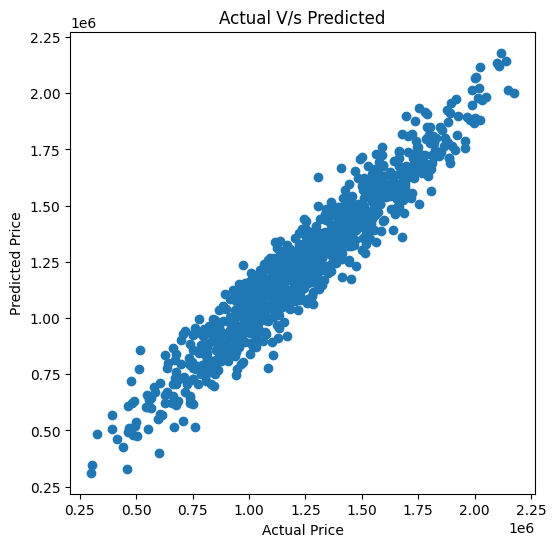

In [116]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual V/s Predicted")
plt.show()

In [118]:
income = float(input("Enter Average Area Income: "))
house_age = float(input("Enter Average Area House Age: "))
rooms = float(input("Enter Average Area Number of Rooms: "))
bedrooms = float(input("Enter Average Area Number of Bedrooms: "))
population = float(input("Enter Area Population: "))

test_input = np.array([[income, house_age, rooms, bedrooms, population]])
predicted_price = mlr_model.predict(test_input)

print("\nPredicted House Price: ${:,.2f}".format(predicted_price[0]))


Predicted House Price: $484,181.48


In [137]:
from sklearn.model_selection import GridSearchCV

In [138]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train,y_train)
ridge_pred=ridge.predict(X_test)
print("Default Ridge R^2 :",r2_score(y_test,ridge_pred))

Default Ridge R^2 : 0.9181377871832105


In [139]:
param_grid={'alpha':[0.001,0.01,1,10,100]}

In [140]:
grid_ridge = GridSearchCV(estimator=Ridge(), param_grid=param_grid, scoring='r2', cv=5)
grid_ridge.fit(X_train, y_train)
print("Best Alpha:", grid_ridge.best_params_)
print(grid_ridge.best_score_)
best_ridge=grid_ridge.best_estimator_
ridge_pred=best_ridge.predict(X_test)

Best Alpha: {'alpha': 1}
0.9103899645949152


In [141]:
mae = mean_absolute_error(y_test, ridge_pred)
mse = mean_squared_error(y_test, ridge_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, ridge_pred)
print("Tuned Ridge Regression Results")
print("------------------------------")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R^2 Score:", r2)

Tuned Ridge Regression Results
------------------------------
MAE: 78456.01211596078
MSE: 9643550061.417933
RMSE: 98201.57871143382
R^2 Score: 0.9181377871832105


In [142]:
from sklearn.linear_model import Lasso
param_grid={'alpha':[0.001,0.01,0.1,1,10]}

In [134]:
grid_lasso=GridSearchCV(Lasso(max_iter=5000),param_grid,cv=5,scoring='r2')
grid_lasso.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso(max_iter=5000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalu

In [135]:
print(grid_lasso.best_params_)

{'alpha': 0.001}


In [136]:
lasso_pred=grid_lasso.predict(X_test)
print(r2_score(y_test,lasso_pred))

0.9181353232692439
